Project 4 - FEMA NRI Bias Evaluation

Group D | CIVE202 | Spring 2026

States: Idaho and Montana

Section 1 - Import packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

# uncomment below if you need to install any packages
#import sys
#!{sys.executable} -m pip install geopandas
#!{sys.executable} -m pip install seaborn

Section 2 - Load the data

Required files (place in working directory):
- NRI_Table_CensusTracts_Idaho.csv
- NRI_Table_CensusTracts_Montana.csv
- Idaho_county.csv
- Montana.csv
- NRIDataDictionary(in).csv
- NRI_Shapefile_CensusTracts.shp (and all accompanying shapefile files)

In [2]:
# loading NRI census tract data for both states
id_nri = pd.read_csv("NRI_Table_CensusTracts_Idaho.csv")
mt_nri = pd.read_csv("NRI_Table_CensusTracts_Montana.csv")

# loading SVI county data for both states
id_svi = pd.read_csv("Idaho_county.csv")
mt_svi = pd.read_csv("Montana.csv")

# loading the data dictionary for reference
nri_dictionary = pd.read_csv("NRIDataDictionary(in).csv")

In [3]:
# making sure Idaho NRI loaded correctly
print("Idaho NRI shape:", id_nri.shape)
id_nri.head(5)

Idaho NRI shape: (456, 467)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,24438,T16001000101,Idaho,ID,16,Ada,County,1,16001,101,...,49.826197,Relatively Low,2.693153e-08,7.146451e-08,4.746257e-08,65.087958,1779.599594,53.278552,Relatively Low,March 2023
1,24439,T16001000102,Idaho,ID,16,Ada,County,1,16001,102,...,64.578293,Relatively Moderate,2.693153e-08,7.146451e-08,4.746257e-08,64.816685,3108.076135,64.869429,Relatively Moderate,March 2023
2,24440,T16001000201,Idaho,ID,16,Ada,County,1,16001,201,...,66.082627,Relatively Moderate,2.693153e-08,7.146451e-08,4.746257e-08,65.504850,2705.807053,61.936926,Relatively Moderate,March 2023
3,24441,T16001000202,Idaho,ID,16,Ada,County,1,16001,202,...,77.274115,Relatively Moderate,2.693153e-08,7.146451e-08,4.746257e-08,65.677478,4301.819896,71.307615,Relatively Moderate,March 2023
4,24442,T16001000302,Idaho,ID,16,Ada,County,1,16001,302,...,65.278202,Relatively Moderate,2.693153e-08,7.146451e-08,4.746257e-08,65.864199,3590.788220,67.704419,Relatively Moderate,March 2023


In [4]:
# checking Montana NRI loaded correctly
print("Montana NRI shape:", mt_nri.shape)
mt_nri.head(5)

Montana NRI shape: (319, 467)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,WNTW_EALS,WNTW_EALR,WNTW_ALRB,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_NPCTL,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER
0,44735,T30001000100,Montana,MT,30,Beaverhead,County,1,30001,100,...,85.440496,Relatively Moderate,1.808075e-07,5.989003e-07,2.451000e-12,96.604975,8348.186110,82.982923,Relatively Moderate,March 2023
1,44736,T30001000200,Montana,MT,30,Beaverhead,County,1,30001,200,...,96.048336,Relatively High,1.814058e-07,6.015477e-07,2.473000e-12,97.432886,30640.862822,95.836703,Relatively High,March 2023
2,44737,T30001000300,Montana,MT,30,Beaverhead,County,1,30001,300,...,96.316086,Relatively High,1.806294e-07,5.984793e-07,2.450000e-12,97.464594,34717.926046,96.458641,Relatively High,March 2023
3,44738,T30003000100,Montana,MT,30,Big Horn,County,3,30003,100,...,95.396576,Relatively High,5.098874e-07,4.392708e-07,6.490903e-07,95.233342,37601.634137,96.818960,Relatively High,March 2023
4,44739,T30003940400,Montana,MT,30,Big Horn,County,3,30003,940400,...,87.694060,Relatively High,7.784739e-07,4.864678e-07,1.032909e-06,95.915635,13756.958025,89.462731,Relatively High,March 2023


In [5]:
# checking Idaho SVI loaded correctly
print("Idaho SVI shape:", id_svi.shape)
id_svi.head(5)

Idaho SVI shape: (44, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,16,Idaho,ID,16001,Ada County,16001,"Ada County, Idaho",1052.014199,497494,0,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1
1,16,Idaho,ID,16003,Adams County,16003,"Adams County, Idaho",1362.804513,4464,0,...,0.0,0.8,0.7,0.6,0.0,0.8,4.9,1.1,0.0,0.8
2,16,Idaho,ID,16005,Bannock County,16005,"Bannock County, Idaho",1112.489755,87434,0,...,1.7,0.2,2.2,0.3,0.2,0.1,3.2,0.4,0.2,0.1
3,16,Idaho,ID,16007,Bear Lake County,16007,"Bear Lake County, Idaho",975.727304,6436,0,...,0.8,0.7,0.3,0.5,0.0,0.6,1.4,0.9,0.5,0.8
4,16,Idaho,ID,16009,Benewah County,16009,"Benewah County, Idaho",776.931014,9731,0,...,0.0,0.1,7.5,0.9,0.3,0.3,3.1,0.7,0.2,0.2


In [6]:
# checking that Montana SVI loaded correctly
print("Montana SVI shape:", mt_svi.shape)
mt_svi.head(5)

Montana SVI shape: (319, 158)


,ST,STATE,ST_ABBR,STCNTY,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,30,Montana,MT,30001,Beaverhead County,30001000100,Census Tract 1; Beaverhead County; Montana,4184.137071,1372,181,...,0.4,0.4,0.1,0.2,0.0,2.0,4.3,2.6,0.4,0.7
1,30,Montana,MT,30001,Beaverhead County,30001000200,Census Tract 2; Beaverhead County; Montana,1348.907396,3863,207,...,0.1,0.1,1.6,1.8,0.0,0.7,1.7,1.1,0.0,0.7
2,30,Montana,MT,30001,Beaverhead County,30001000300,Census Tract 3; Beaverhead County; Montana,9.639751,4234,135,...,0.2,0.3,3.0,1.9,0.0,0.1,1.7,1.1,0.0,0.6
3,30,Montana,MT,30003,Big Horn County,30003000100,Census Tract 1; Big Horn County; Montana,863.167370,4473,263,...,0.6,0.8,31.7,6.6,0.0,0.6,4.4,2.2,0.0,0.6
4,30,Montana,MT,30003,Big Horn County,30003940400,Census Tract 9404; Big Horn County; Montana,925.512349,1675,224,...,0.0,1.6,84.7,5.4,0.0,1.6,1.7,2.1,0.0,1.6


Section 3 - Check for missing values

Using isna() to find where NAs exist before we do anything else to the data.

In [7]:
# checking for NAs in Idaho NRI
print("Idaho NRI missing values:")
print(id_nri.isna().sum())

Idaho NRI missing values:
OID_              0
NRI_ID            0
STATE             0
STATEABBRV        0
STATEFIPS         0
                 ..
WNTW_ALR_NPCTL    0
WNTW_RISKV        0
WNTW_RISKS        0
WNTW_RISKR        0
NRI_VER           0
Length: 467, dtype: int64


In [8]:
# checking for NAs in Montana NRI
print("Montana NRI missing values:")
print(mt_nri.isna().sum())

Montana NRI missing values:
OID_              0
NRI_ID            0
STATE             0
STATEABBRV        0
STATEFIPS         0
                 ..
WNTW_ALR_NPCTL    0
WNTW_RISKV        0
WNTW_RISKS        0
WNTW_RISKR        0
NRI_VER           0
Length: 467, dtype: int64


In [9]:
# checking for NAs in Idaho SVI
print("Idaho SVI missing values:")
print(id_svi.isna().sum())

Idaho SVI missing values:
ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64


In [10]:
# checking for NAs in Montana SVI
print("Montana SVI missing values:")
print(mt_svi.isna().sum())

Montana SVI missing values:
ST              0
STATE           0
ST_ABBR         0
STCNTY          0
COUNTY          0
               ..
MP_NHPI         0
EP_TWOMORE      0
MP_TWOMORE      0
EP_OTHERRACE    0
MP_OTHERRACE    0
Length: 158, dtype: int64


Section 4 - Handle missing values

The NRI dataset uses -9999 as a placeholder for missing data. Were replacing those with NaN. Then we drop columns where every value is missing using dropna(axis=1). For remaining NAs we'll fill with 0, which treats missing  data as not contributing to the risk.

In [11]:
# replacing -9999 placeholder values with NaN
id_nri = id_nri.replace(-9999, np.nan)
mt_nri = mt_nri.replace(-9999, np.nan)

In [12]:
# dropping columns where all the values are missing
id_nri = id_nri.dropna(axis=1)
mt_nri = mt_nri.dropna(axis=1)

print(f"Idaho NRI columns remaining: {id_nri.shape[1]}")
print(f"Montana NRI columns remaining: {mt_nri.shape[1]}")

Idaho NRI columns remaining: 366
Montana NRI columns remaining: 366


In [13]:
# replacing -999 placeholders in SVI data then filling remaining NAs with 0
id_svi = id_svi.replace(-999, np.nan)
mt_svi = mt_svi.replace(-999, np.nan)
id_svi = id_svi.fillna(0)
mt_svi = mt_svi.fillna(0)

print("NAs filled with 0")



NAs filled with 0


Section 5 - Convert data types

Making sure the FIPS join key is the same type in both datasets before we merge. The NRI stores STCOFIPS as an integer and the SVI stores STCNTY as a float so were gonna convert both to string to be safe.

In [14]:
# checking data types before conversion
print("Idaho NRI STCOFIPS type:", id_nri['STCOFIPS'].dtype)
print("Idaho SVI STCNTY type:", id_svi['STCNTY'].dtype)
print("Montana NRI STCOFIPS type:", mt_nri['STCOFIPS'].dtype)
print("Montana SVI STCNTY type:", mt_svi['STCNTY'].dtype)

Idaho NRI STCOFIPS type: int64
Idaho SVI STCNTY type: int64
Montana NRI STCOFIPS type: int64
Montana SVI STCNTY type: int64


In [15]:
# converting FIPS columns to string so the merge key type matches
id_nri['STCOFIPS'] = id_nri['STCOFIPS'].astype(str)
mt_nri['STCOFIPS'] = mt_nri['STCOFIPS'].astype(str)
id_svi['STCNTY'] = id_svi['STCNTY'].astype(str)
mt_svi['STCNTY'] = mt_svi['STCNTY'].astype(str)

print("Data types after conversion:")
print("Idaho NRI STCOFIPS:", id_nri['STCOFIPS'].dtype)
print("Idaho SVI STCNTY:", id_svi['STCNTY'].dtype)

Data types after conversion:
Idaho NRI STCOFIPS: str
Idaho SVI STCNTY: str


Section 6 - Merge NRI and SVI datasets

Both datasets share a county FIPS code. The NRI calls it STCOFIPS and the SVI calls it STCNTY. We create a matching column in the SVI then merge on that key.

In [16]:
# creating the matching join key in the SVI datasets
id_svi['STCOFIPS'] = id_svi['STCNTY']
mt_svi['STCOFIPS'] = mt_svi['STCNTY']

C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\513105239.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  id_svi['STCOFIPS'] = id_svi['STCNTY']
C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\513105239.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mt_svi['STCOFIPS'] = mt_svi['STCNTY']


In [17]:
# merging Idaho NRI and SVI
id_complete = pd.merge(id_nri, id_svi, on='STCOFIPS', suffixes=('', '_svi'))

print(f"Idaho merged shape: {id_complete.shape}")
id_complete.head(5)

Idaho merged shape: (456, 524)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,24438,T16001000101,Idaho,ID,16,Ada,County,1,16001,101,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1
1,24439,T16001000102,Idaho,ID,16,Ada,County,1,16001,102,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1
2,24440,T16001000201,Idaho,ID,16,Ada,County,1,16001,201,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1
3,24441,T16001000202,Idaho,ID,16,Ada,County,1,16001,202,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1
4,24442,T16001000302,Idaho,ID,16,Ada,County,1,16001,302,...,2.5,0.2,0.3,0.1,0.2,0.1,3.7,0.3,0.5,0.1


In [18]:
# merging Montana NRI and SVI
mt_complete = pd.merge(mt_nri, mt_svi, on='STCOFIPS', suffixes=('', '_svi'))

print(f"Montana merged shape: {mt_complete.shape}")
mt_complete.head(5)

Montana merged shape: (5539, 524)


,OID_,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,...,EP_ASIAN,MP_ASIAN,EP_AIAN,MP_AIAN,EP_NHPI,MP_NHPI,EP_TWOMORE,MP_TWOMORE,EP_OTHERRACE,MP_OTHERRACE
0,44735,T30001000100,Montana,MT,30,Beaverhead,County,1,30001,100,...,0.4,0.4,0.1,0.2,0.0,2.0,4.3,2.6,0.4,0.7
1,44735,T30001000100,Montana,MT,30,Beaverhead,County,1,30001,100,...,0.1,0.1,1.6,1.8,0.0,0.7,1.7,1.1,0.0,0.7
2,44735,T30001000100,Montana,MT,30,Beaverhead,County,1,30001,100,...,0.2,0.3,3.0,1.9,0.0,0.1,1.7,1.1,0.0,0.6
3,44736,T30001000200,Montana,MT,30,Beaverhead,County,1,30001,200,...,0.4,0.4,0.1,0.2,0.0,2.0,4.3,2.6,0.4,0.7
4,44736,T30001000200,Montana,MT,30,Beaverhead,County,1,30001,200,...,0.1,0.1,1.6,1.8,0.0,0.7,1.7,1.1,0.0,0.7


Section 7 - Apply the alternative risk definition

Our risk definition is:

Risk = EAL_VALT x RPL_THEMES x (1 - (RESL_SCORE / 100))

EAL_VALT is Expected Annual Loss in dollars. RPL_THEMES is the SVI composite score from 0 to 1 where 1 is most vulnerable. RESL_SCORE is community resilience from 0 to 100 where higher means more resilient; subtracting from 1 flips it so that a more resilient community lowers the risk score.

In [19]:
# pulling the SVI composite score into its own column
id_complete['SVI'] = id_complete['RPL_THEMES']
mt_complete['SVI'] = mt_complete['RPL_THEMES']

C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\3981186178.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  id_complete['SVI'] = id_complete['RPL_THEMES']
C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\3981186178.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mt_complete['SVI'] = mt_complete['RPL_THEMES']


In [20]:
# creating the resilience factor - high resilience score means lower risk
id_complete['Resilience_factor'] = 1 - (id_complete['RESL_SCORE'] / 100)
mt_complete['Resilience_factor'] = 1 - (mt_complete['RESL_SCORE'] / 100)

C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\2138459054.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  id_complete['Resilience_factor'] = 1 - (id_complete['RESL_SCORE'] / 100)
C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\2138459054.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mt_complete['Resilience_factor'] = 1 - (mt_complete['RESL_SCORE'] / 100)


In [21]:
# calculating the alternative risk score
id_complete['my_risk'] = id_complete['EAL_VALT'] * id_complete['SVI'] * id_complete['Resilience_factor']
mt_complete['my_risk'] = mt_complete['EAL_VALT'] * mt_complete['SVI'] * mt_complete['Resilience_factor']

# spot check Idaho to make sure the math looks right
print(id_complete[['TRACTFIPS', 'COUNTY', 'EAL_VALT', 'SVI', 'Resilience_factor', 'my_risk', 'RISK_SCORE']].head(10))

C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\409048021.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  id_complete['my_risk'] = id_complete['EAL_VALT'] * id_complete['SVI'] * id_complete['Resilience_factor']
C:\Users\nickm\AppData\Local\Temp\ipykernel_20300\409048021.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mt_complete['my_risk'] = mt_complete['EAL_VALT'] * mt_complete['SVI'] * mt_complete['Resilience_factor']


     TRACTFIPS COUNTY      EAL_VALT     SVI  Resilience_factor       my_risk  \
0  16001000101    Ada  1.615271e+05  0.2093             0.2513   8495.857114   
1  16001000102    Ada  3.880588e+05  0.2093             0.2513  20410.759462   
2  16001000201    Ada  3.298960e+05  0.2093             0.2513  17351.569713   
3  16001000202    Ada  1.381511e+06  0.2093             0.2513  72663.424716   
4  16001000302    Ada  1.313291e+05  0.2093             0.2513   6907.527812   
5  16001000303    Ada  1.180059e+05  0.2093             0.2513   6206.767391   
6  16001000305    Ada  7.333292e+04  0.2093             0.2513   3857.097639   
7  16001000306    Ada  1.559930e+05  0.2093             0.2513   8204.777012   
8  16001000401    Ada  6.950382e+04  0.2093             0.2513   3655.698438   
9  16001000402    Ada  1.362939e+05  0.2093             0.2513   7168.663852   

   RISK_SCORE  
0   19.251534  
1   42.927984  
2   29.248918  
3   73.907149  
4   12.894211  
5    7.243257  
6    2.

In [22]:
#  check Montana
print(mt_complete[['TRACTFIPS', 'COUNTY', 'EAL_VALT', 'SVI', 'Resilience_factor', 'my_risk', 'RISK_SCORE']].head(10))

     TRACTFIPS      COUNTY      EAL_VALT     SVI  Resilience_factor  \
0  30001000100  Beaverhead  7.432415e+05  0.2500             0.8051   
1  30001000100  Beaverhead  7.432415e+05  0.5000             0.8051   
2  30001000100  Beaverhead  7.432415e+05  0.6456             0.8051   
3  30001000200  Beaverhead  8.131427e+05  0.2500             0.8051   
4  30001000200  Beaverhead  8.131427e+05  0.5000             0.8051   
5  30001000200  Beaverhead  8.131427e+05  0.6456             0.8051   
6  30001000300  Beaverhead  7.569977e+05  0.2500             0.8051   
7  30001000300  Beaverhead  7.569977e+05  0.5000             0.8051   
8  30001000300  Beaverhead  7.569977e+05  0.6456             0.8051   
9  30003000100    Big Horn  1.078363e+06  0.8671             0.8939   

         my_risk  RISK_SCORE  
0  149595.941936   60.239975  
1  299191.883872   60.239975  
2  386316.560455   60.239975  
3  163665.303498   67.640204  
4  327330.606997   67.640204  
5  422649.279754   67.640204  
6

Section 8 - Summary statistics

In [23]:
# summary stats for Idaho
print("Idaho - NRI Risk Score")
print(id_complete['RISK_SCORE'].describe())
print()
print("Idaho - Alternative Risk Score")
print(id_complete['my_risk'].describe())

Idaho - NRI Risk Score
count    456.000000
mean      31.562109
std       27.842731
min        0.456643
25%        8.493674
50%       21.890311
75%       50.810422
max       99.444656
Name: RISK_SCORE, dtype: float64

Idaho - Alternative Risk Score
count    4.560000e+02
mean     1.565959e+05
std      4.202949e+05
min      0.000000e+00
25%      1.078209e+04
50%      3.903242e+04
75%      1.102713e+05
max      4.249293e+06
Name: my_risk, dtype: float64


In [24]:
# summary stats for Montana
print("Montana - NRI Risk Score")
print(mt_complete['RISK_SCORE'].describe())
print()
print("Montana - Alternative Risk Score")
print(mt_complete['my_risk'].describe())

Montana - NRI Risk Score
count    5539.000000
mean       42.848529
std        24.963681
min         0.233078
25%        20.011416
50%        44.569043
75%        64.725539
max        97.568140
Name: RISK_SCORE, dtype: float64

Montana - Alternative Risk Score
count    5.539000e+03
mean     1.311465e+05
std      2.201911e+05
min      0.000000e+00
25%      1.940776e+04
50%      5.606068e+04
75%      1.523948e+05
max      3.257728e+06
Name: my_risk, dtype: float64


Section 9 - Group by county and plot

Grouping by county to get mean risk scores then plotting bar charts to compare the NRI and alternative methods.

In [25]:
# grouping Idaho by county - mean of both risk scores
id_grouped = id_complete.groupby('COUNTY').agg(
    mean_nri_risk=('RISK_SCORE', 'mean'),
    mean_my_risk=('my_risk', 'mean')
)

print(id_grouped)

            mean_nri_risk  mean_my_risk
COUNTY                                 
Ada             14.868424  1.694998e+04
Adams           94.042239  3.452500e+05
Bannock         30.182271  9.782211e+04
Bear Lake       55.026637  6.606981e+04
Benewah         53.365362  2.814551e+05
Bingham         47.585026  2.007350e+05
Blaine          55.399889  2.179220e+05
Boise           92.981496  2.077340e+05
Bonner          22.127922  5.792060e+04
Bonneville      41.068413  2.141190e+04
Boundary        79.789992  4.713029e+05
Butte           63.166532  4.524808e+05
Camas           53.970651  1.100674e+05
Canyon          16.048517  6.030674e+04
Caribou         67.217452  5.450161e+04
Cassia          54.293314  4.598830e+05
Clark           69.602340  4.123157e+05
Clearwater      69.452504  4.989276e+05
Custer          88.847928  6.074653e+05
Elmore          61.998593  1.697014e+06
Franklin        61.477311  1.177011e+04
Fremont         70.847703  4.888277e+05
Gem             73.877123  5.094175e+05


In [26]:
# grouping Montana by county
mt_grouped = mt_complete.groupby('COUNTY').agg(
    mean_nri_risk=('RISK_SCORE', 'mean'),
    mean_my_risk=('my_risk', 'mean')
)

print(mt_grouped)

                 mean_nri_risk   mean_my_risk
COUNTY                                       
Beaverhead           65.142939  288812.261787
Big Horn             51.243876  382978.267816
Blaine               47.992377  317200.151436
Broadwater           47.965324  178307.550675
Carbon               53.411740   99030.613881
Carter               53.373686  387304.365845
Cascade              26.283451   35471.286084
Chouteau             46.442587  218293.600844
Custer               55.461281  226543.965771
Daniels              58.791562  250065.887897
Dawson               56.953099   61483.942417
Deer Lodge           49.904866  225603.675139
Fallon               61.851306  191181.958519
Fergus               41.083972  114294.017328
Flathead             60.729878  206228.439076
Gallatin             42.014332   68389.984371
Garfield             51.689816   73947.807564
Glacier              46.591531  302189.760175
Golden Valley        20.713029   97331.706052
Granite              66.512272  34

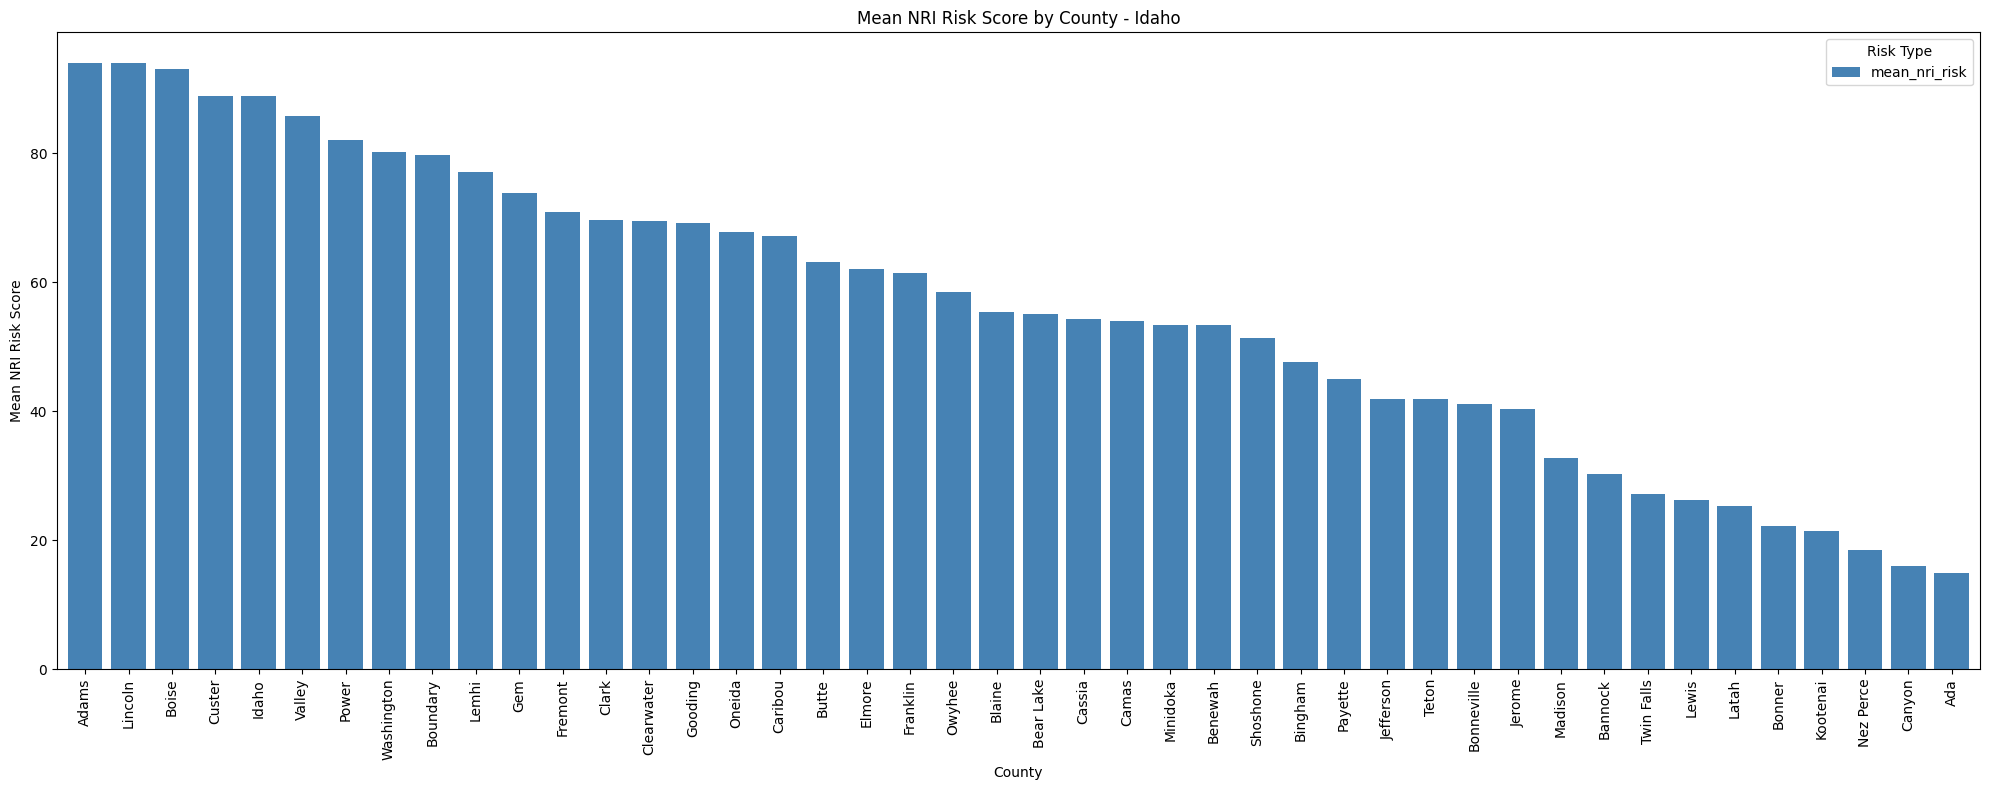

In [27]:
# Idaho bar chart - NRI risk score by county
id_grouped_sorted = id_grouped.sort_values('mean_nri_risk', ascending=False)

id_grouped_sorted[['mean_nri_risk']].plot(kind='bar', figsize=(20, 8), width=0.8, color='steelblue')

plt.xlabel('County')
plt.ylabel('Mean NRI Risk Score')
plt.title('Mean NRI Risk Score by County - Idaho')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

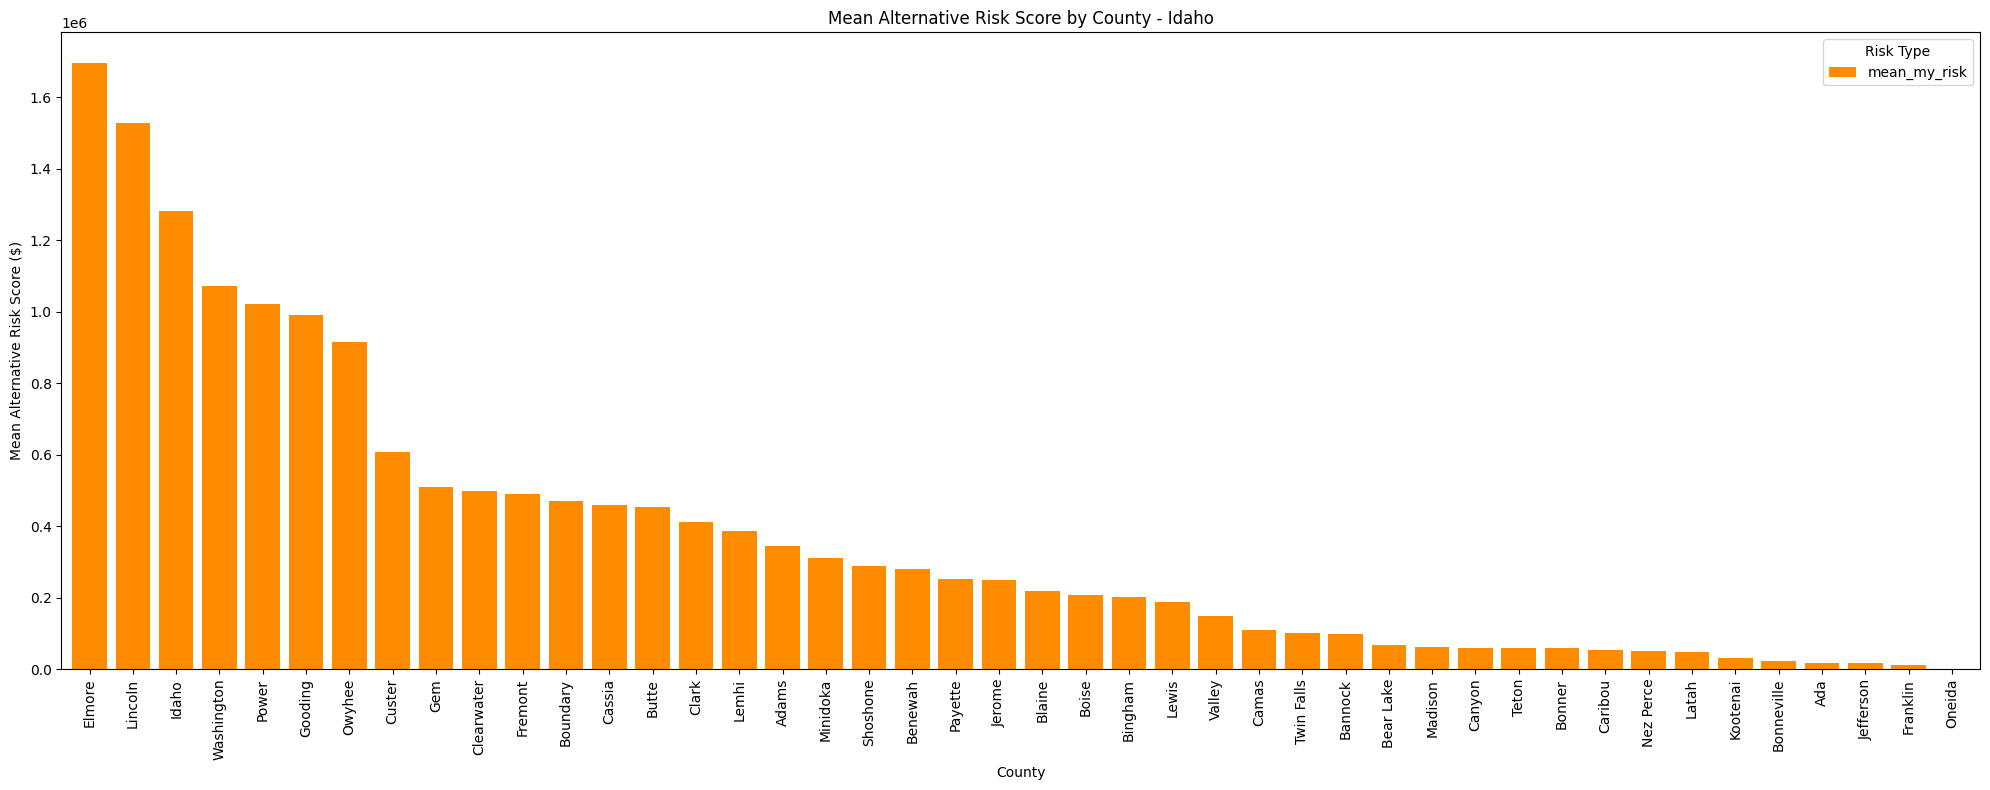

In [28]:
# Idaho bar chart - alternative risk score by county
id_grouped_sorted2 = id_grouped.sort_values('mean_my_risk', ascending=False)

id_grouped_sorted2[['mean_my_risk']].plot(kind='bar', figsize=(20, 8), width=0.8, color='darkorange')

plt.xlabel('County')
plt.ylabel('Mean Alternative Risk Score ($)')
plt.title('Mean Alternative Risk Score by County - Idaho')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

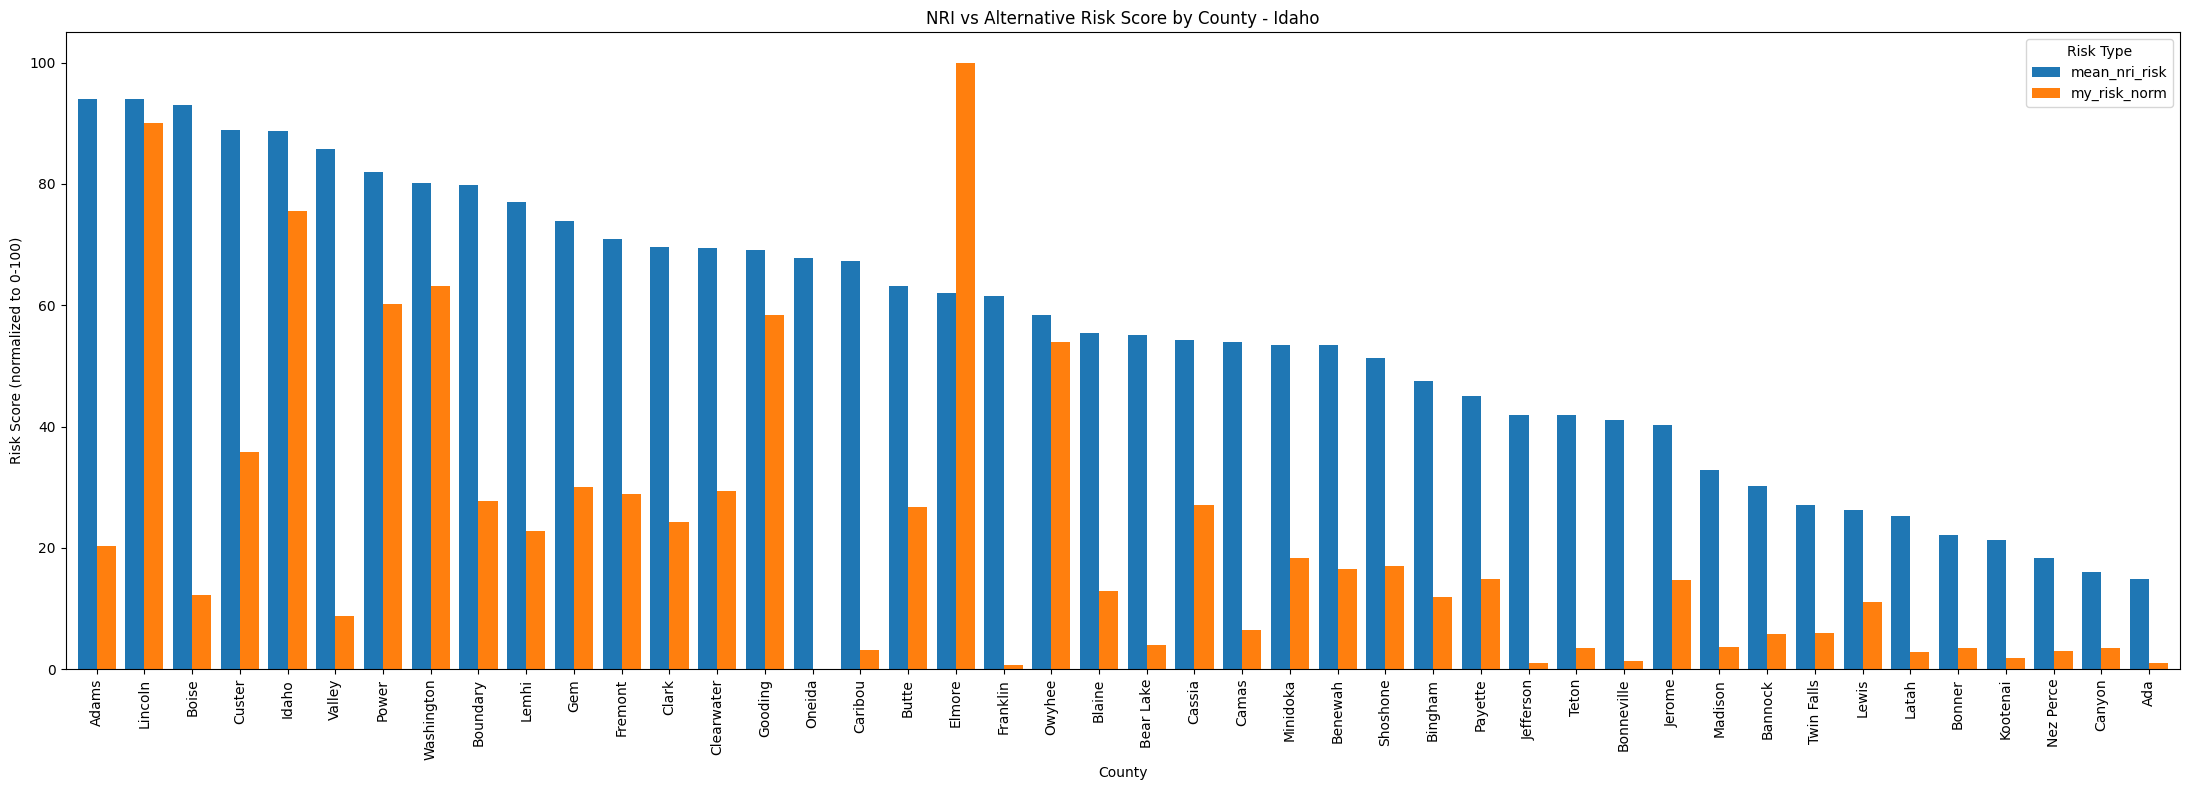

In [29]:
# Idaho side by side comparison - both scores normalized to 0-100 so they are visually comparable
id_grouped['my_risk_norm'] = (
    (id_grouped['mean_my_risk'] - id_grouped['mean_my_risk'].min()) /
    (id_grouped['mean_my_risk'].max() - id_grouped['mean_my_risk'].min())
) * 100

id_grouped_sorted3 = id_grouped.sort_values('mean_nri_risk', ascending=False)

id_grouped_sorted3[['mean_nri_risk', 'my_risk_norm']].plot(kind='bar', figsize=(22, 8), width=0.8)

plt.xlabel('County')
plt.ylabel('Risk Score (normalized to 0-100)')
plt.title('NRI vs Alternative Risk Score by County - Idaho')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

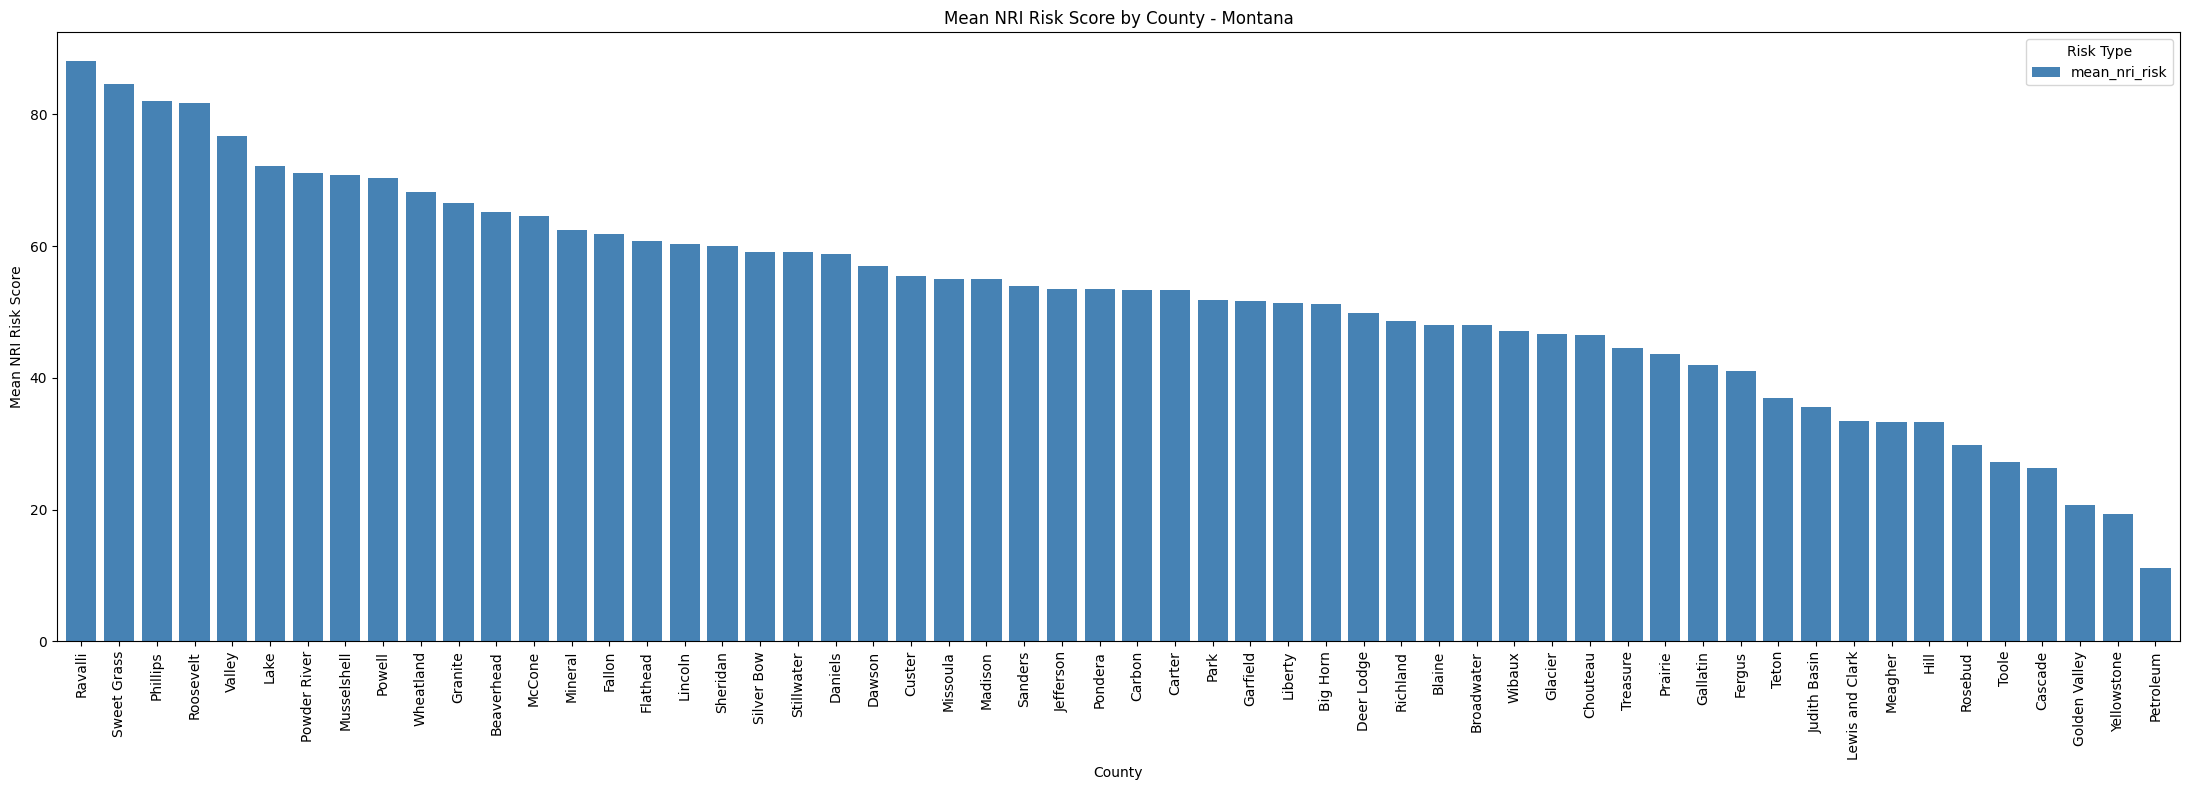

In [30]:
# Montana bar chart - NRI risk score by county
mt_grouped_sorted = mt_grouped.sort_values('mean_nri_risk', ascending=False)

mt_grouped_sorted[['mean_nri_risk']].plot(kind='bar', figsize=(22, 8), width=0.8, color='steelblue')

plt.xlabel('County')
plt.ylabel('Mean NRI Risk Score')
plt.title('Mean NRI Risk Score by County - Montana')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

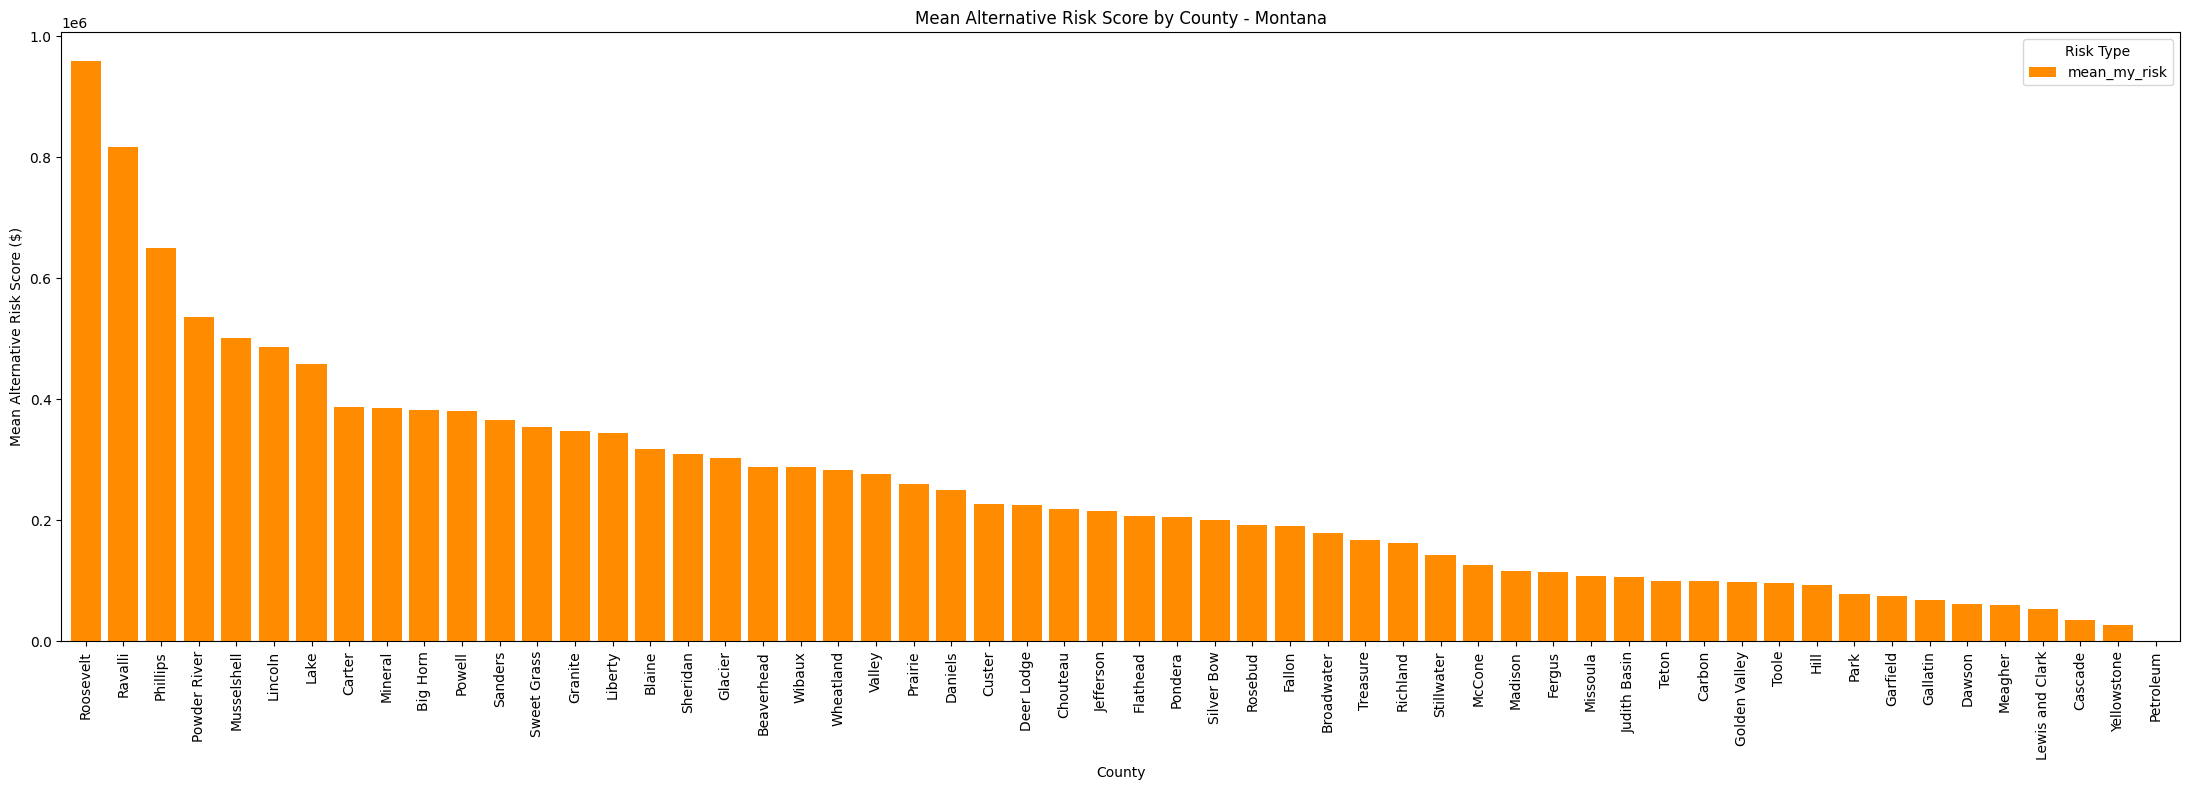

In [31]:
# Montana bar chart - alternative risk score by county
mt_grouped_sorted2 = mt_grouped.sort_values('mean_my_risk', ascending=False)

mt_grouped_sorted2[['mean_my_risk']].plot(kind='bar', figsize=(22, 8), width=0.8, color='darkorange')

plt.xlabel('County')
plt.ylabel('Mean Alternative Risk Score ($)')
plt.title('Mean Alternative Risk Score by County - Montana')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

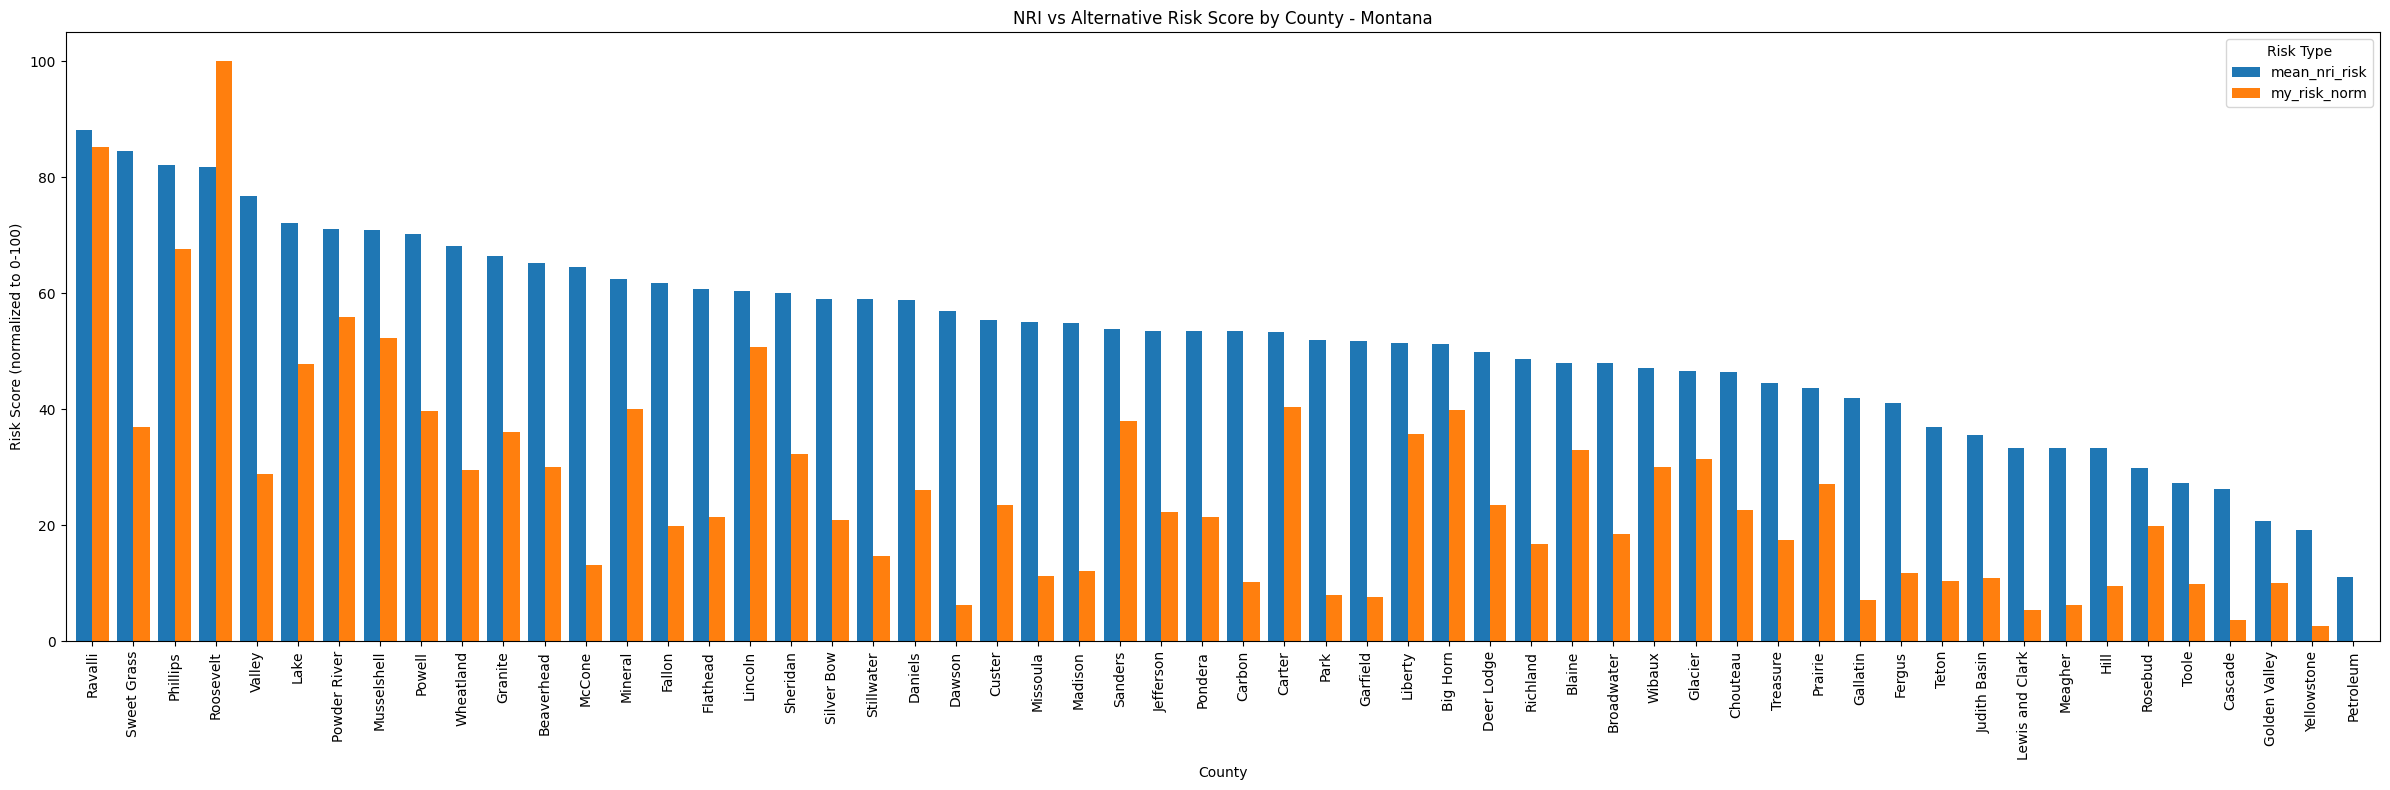

In [32]:
# Montana side by side comparison
mt_grouped['my_risk_norm'] = (
    (mt_grouped['mean_my_risk'] - mt_grouped['mean_my_risk'].min()) /
    (mt_grouped['mean_my_risk'].max() - mt_grouped['mean_my_risk'].min())
) * 100

mt_grouped_sorted3 = mt_grouped.sort_values('mean_nri_risk', ascending=False)

mt_grouped_sorted3[['mean_nri_risk', 'my_risk_norm']].plot(kind='bar', figsize=(24, 8), width=0.8)

plt.xlabel('County')
plt.ylabel('Risk Score (normalized to 0-100)')
plt.title('NRI vs Alternative Risk Score by County - Montana')
plt.xticks(rotation=90)
plt.legend(title='Risk Type')
plt.tight_layout()
plt.show()

Section 10 - GeoPandas mapping

Loading the NRI shapefile and attaching our alternative risk scores to it so we can map both scoring methods for Idaho and Montana.

In [33]:
# loading the census tract shapefile
tracts = gpd.read_file("NRI_Shapefile_CensusTracts.shp")
tracts.head()



,NRI_ID,STATE,STATEABBRV,STATEFIPS,COUNTY,COUNTYTYPE,COUNTYFIPS,STCOFIPS,TRACT,TRACTFIPS,...,WNTW_ALRP,WNTW_ALRA,WNTW_ALR_N,WNTW_RISKV,WNTW_RISKS,WNTW_RISKR,NRI_VER,Shape_Leng,Shape_Area,geometry
0,T01001020100,Alabama,AL,01,Autauga,County,001,01001,020100,01001020100,...,7.410082e-09,0.000009,32.947366,214.404773,25.882367,Relatively Low,March 2023,19225.811017,1.388551e+07,"POLYGON ((-9626784.493 3827718.774, -9626802.4..."
1,T01001020200,Alabama,AL,01,Autauga,County,001,01001,020200,01001020200,...,7.410082e-09,0.000009,33.845738,335.526352,29.020596,Relatively Low,March 2023,11645.802680,4.687259e+06,"POLYGON ((-9625497.973 3827700.43, -9625504.76..."
2,T01001020300,Alabama,AL,01,Autauga,County,001,01001,020300,01001020300,...,7.410082e-09,0.000009,33.386570,494.226826,32.839033,Relatively Low,March 2023,12474.652420,7.550456e+06,"POLYGON ((-9623646.617 3823891.992, -9623666.3..."
3,T01001020400,Alabama,AL,01,Autauga,County,001,01001,020400,01001020400,...,7.410082e-09,0.000009,32.654955,517.167844,33.357513,Relatively Low,March 2023,14839.600848,9.007297e+06,"POLYGON ((-9622012.001 3826514.039, -9622007.2..."
4,T01001020501,Alabama,AL,01,Autauga,County,001,01001,020501,01001020501,...,7.410082e-09,0.000009,32.793527,558.901021,34.226799,Relatively Low,March 2023,13543.791893,8.736313e+06,"POLYGON ((-9619304.709 3823820.353, -9619304.3..."


In [34]:
# cleaning the shapefile - setting projection and replacing -9999 placeholders
tracts_clean = tracts.set_crs(epsg=4326, inplace=True, allow_override=True)
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.replace(-9999, np.nan)

# converting to standard US national projection
tracts_clean.crs = "EPSG:3857"
tracts_clean = tracts_clean.to_crs(epsg=4326)
tracts_clean = tracts_clean.to_crs("ESRI:102003")

print(tracts_clean.crs)

ESRI:102003


In [35]:
# converting TRACTFIPS to string in all datasets so the join key type matches
id_complete['TRACTFIPS'] = id_complete['TRACTFIPS'].astype(str)
mt_complete['TRACTFIPS'] = mt_complete['TRACTFIPS'].astype(str)
tracts_clean['TRACTFIPS'] = tracts_clean['TRACTFIPS'].astype(str)

In [36]:
# merging Idaho alternative risk scores into the shapefile
id_risk = id_complete[['TRACTFIPS', 'my_risk']]
tracts_clean = tracts_clean.merge(id_risk, on='TRACTFIPS', how='left')
tracts_clean = tracts_clean.rename(columns={'my_risk': 'id_my_risk'})

# merging Montana alternative risk scores into the shapefile
mt_risk = mt_complete[['TRACTFIPS', 'my_risk']]
tracts_clean = tracts_clean.merge(mt_risk, on='TRACTFIPS', how='left')
tracts_clean = tracts_clean.rename(columns={'my_risk': 'mt_my_risk'})

# combining into one column for plotting
tracts_clean['my_risk'] = tracts_clean['id_my_risk'].fillna(tracts_clean['mt_my_risk'])

print("Alternative risk scores joined to shapefile")

Alternative risk scores joined to shapefile


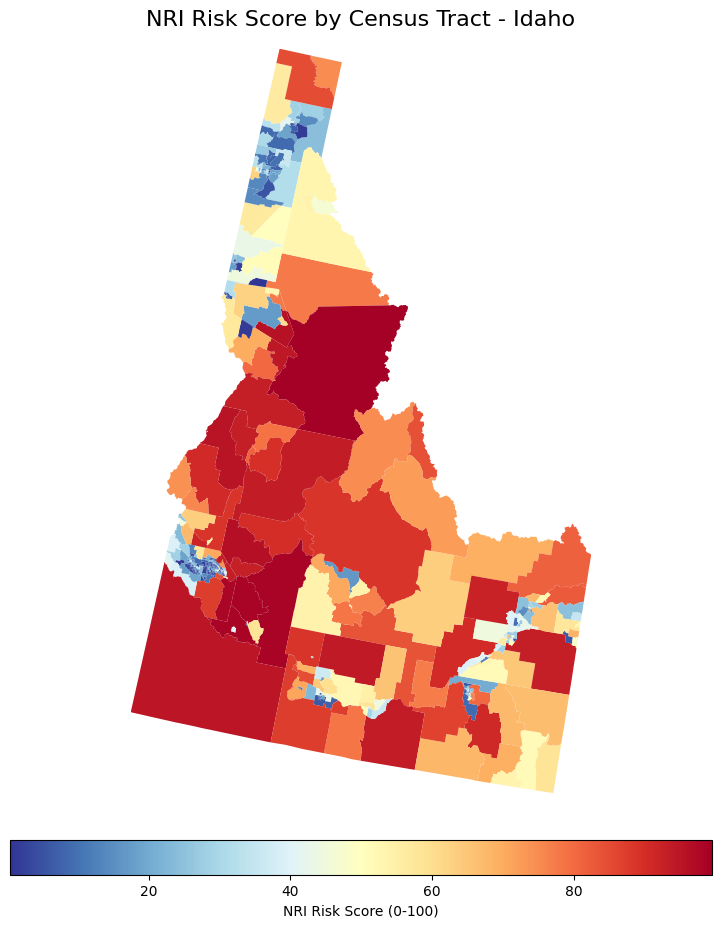

In [37]:
# map 1 - NRI risk score for Idaho
state_name = "Idaho"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column="RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.0,
    cmap="RdYlBu_r",
    legend_kwds={"label": "NRI Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("NRI Risk Score by Census Tract - Idaho", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

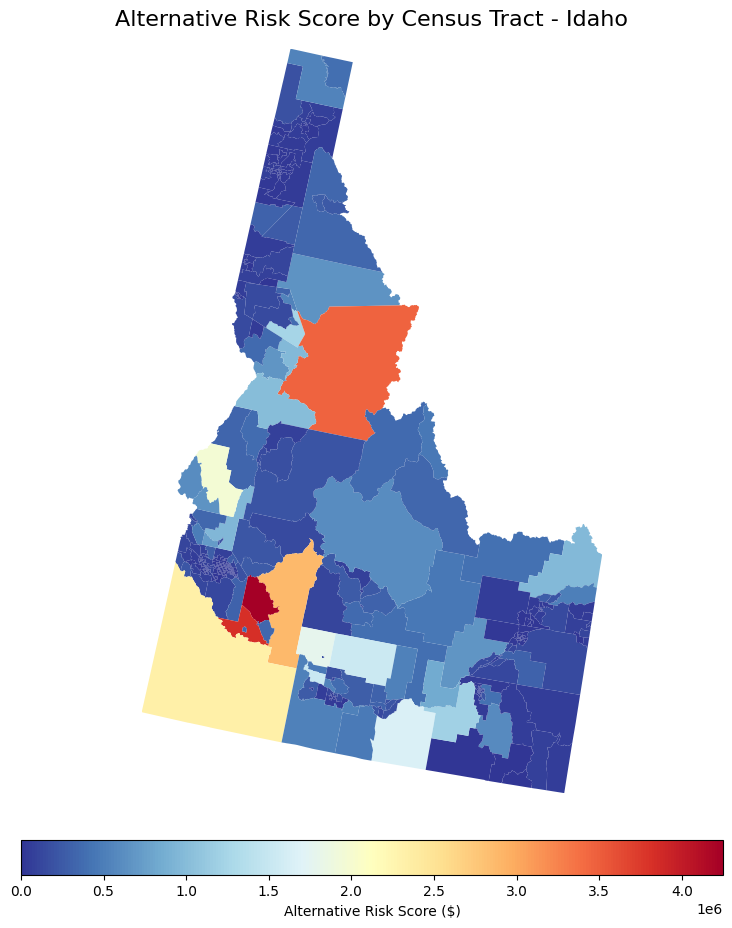

In [38]:
# map 2 - alternative risk score for Idaho
state_name = "Idaho"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column="my_risk",
    ax=ax,
    legend=True,
    linewidth=0.0,
    cmap="RdYlBu_r",
    legend_kwds={"label": "Alternative Risk Score ($)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Alternative Risk Score by Census Tract - Idaho", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

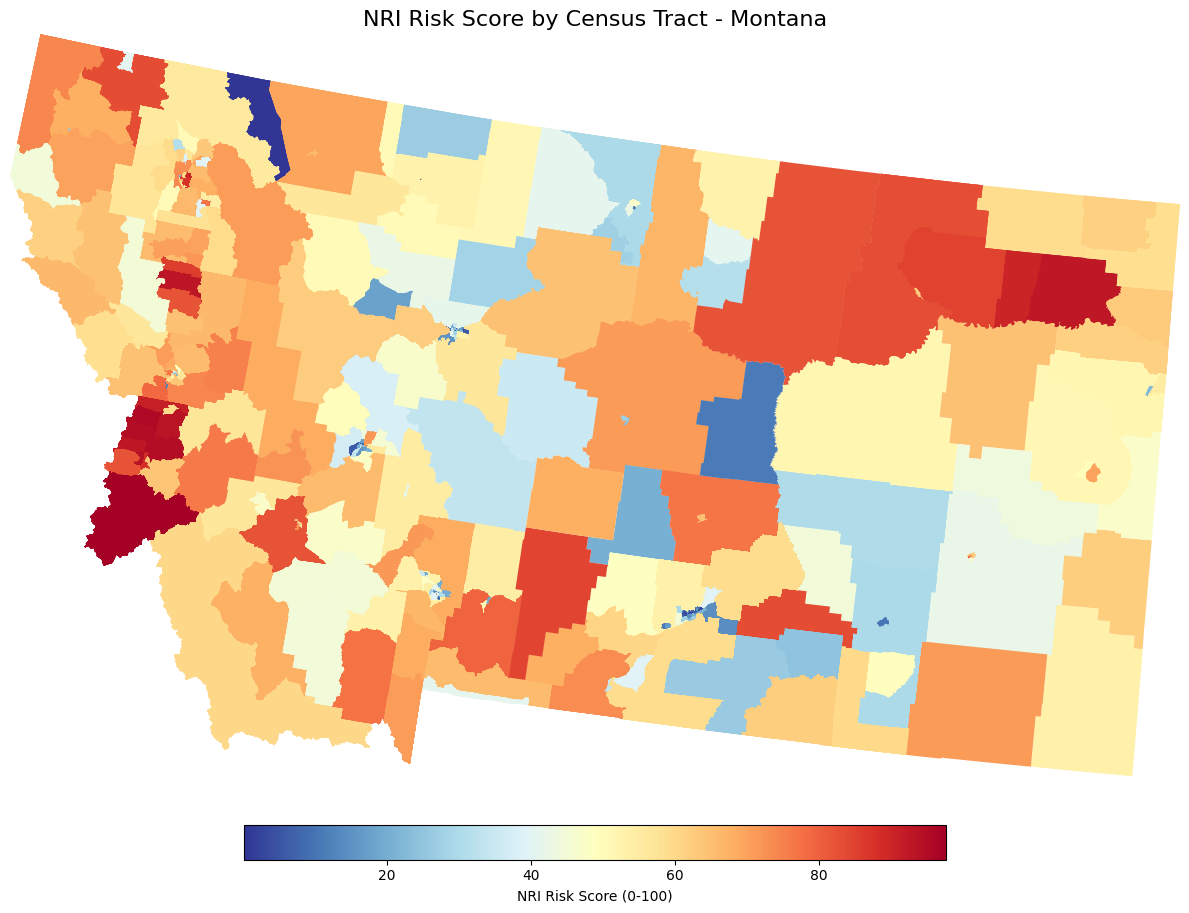

In [39]:
# map 3 - NRI risk score for Montana
state_name = "Montana"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column="RISK_SCORE",
    ax=ax,
    legend=True,
    linewidth=0.0,
    cmap="RdYlBu_r",
    legend_kwds={"label": "NRI Risk Score (0-100)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("NRI Risk Score by Census Tract - Montana", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

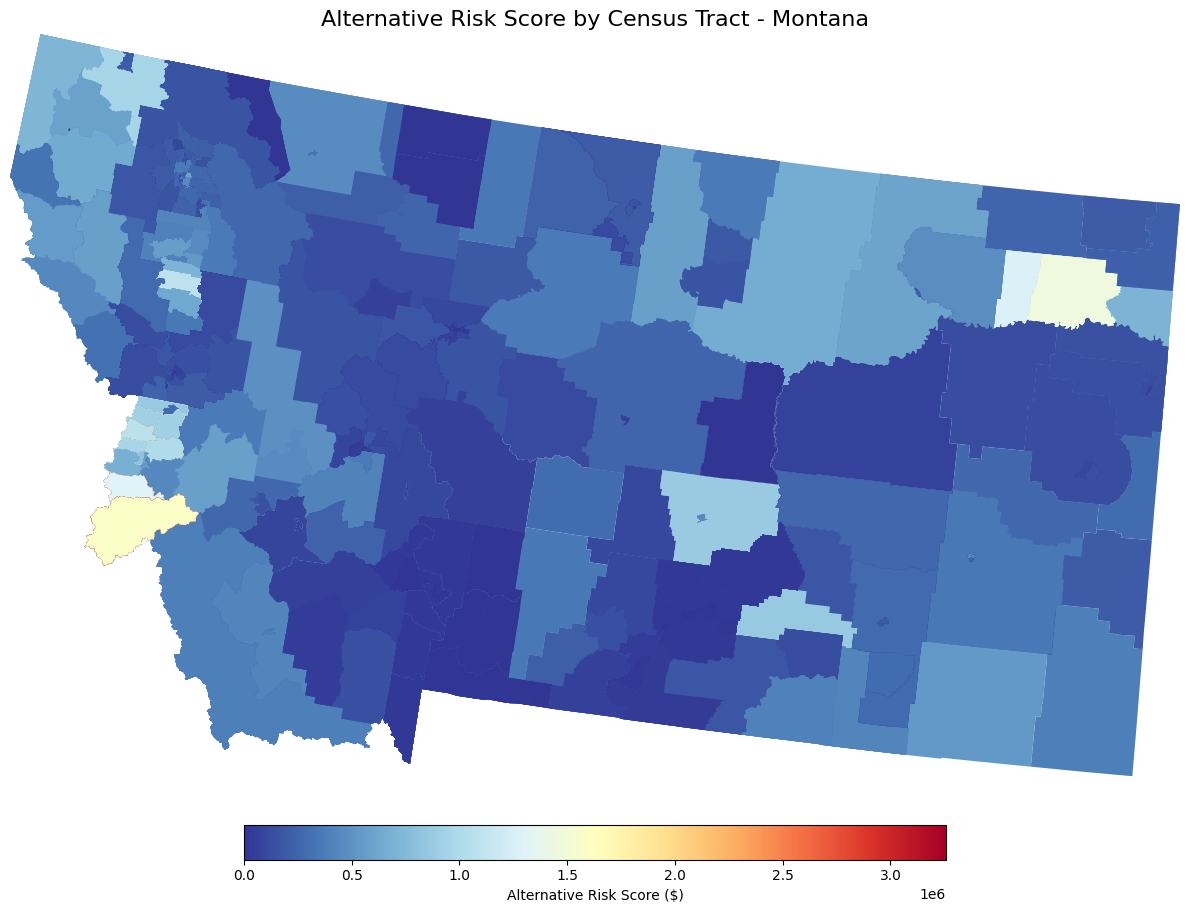

In [40]:
# map 4 - alternative risk score for Montana
state_name = "Montana"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column="my_risk",
    ax=ax,
    legend=True,
    linewidth=0.0,
    cmap="RdYlBu_r",
    legend_kwds={"label": "Alternative Risk Score ($)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.05},
    missing_kwds={"color": "lightgrey", "label": "No Data"}
)

minx, miny, maxx, maxy = state_map.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("Alternative Risk Score by Census Tract - Montana", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

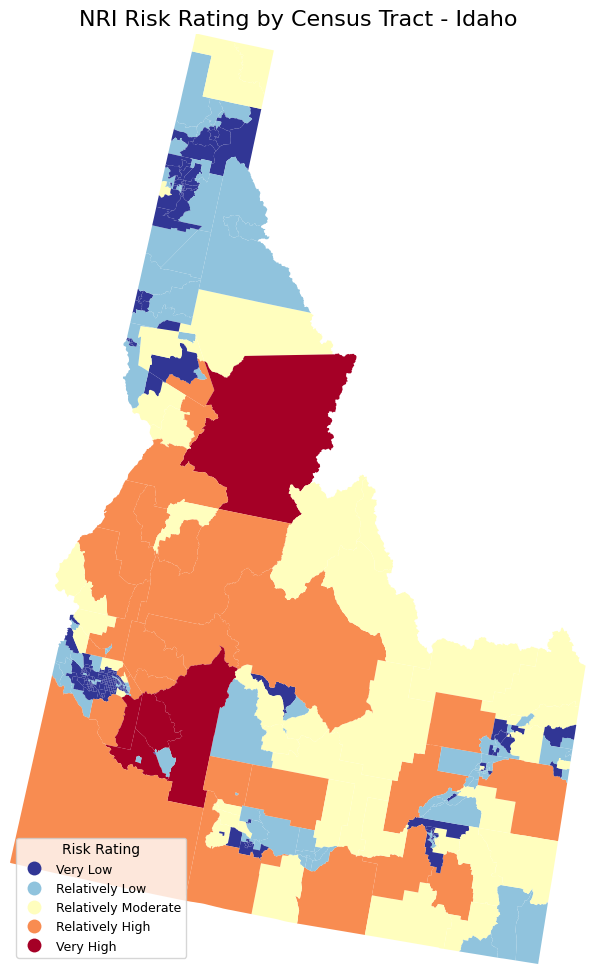

In [45]:
state_name = "Idaho"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

rated = state_map[state_map["RISK_RATNG"].isin(rating_order)]
rated = rated.copy()
rated["RISK_RATNG"] = pd.Categorical(rated["RISK_RATNG"], categories=rating_order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(14, 10))
rated.plot(column="RISK_RATNG", ax=ax, legend=True, linewidth=0.0,
           cmap="RdYlBu_r",
           legend_kwds={"loc": "lower left", "fontsize": 9, "title": "Risk Rating"})

minx, miny, maxx, maxy = rated.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("NRI Risk Rating by Census Tract - Idaho", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

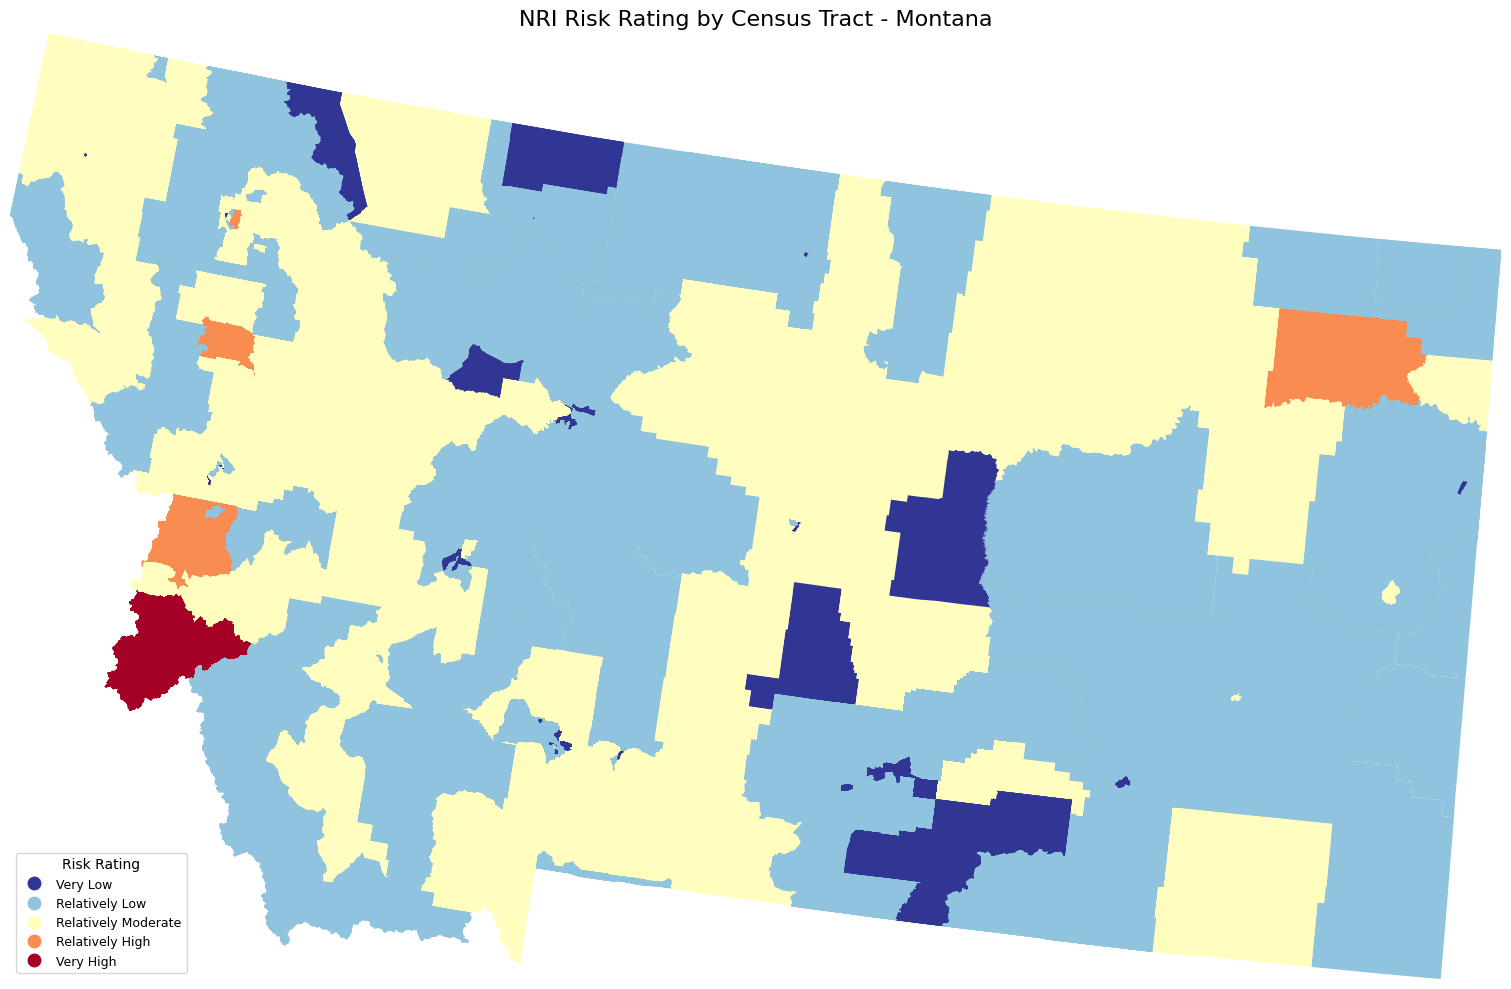

In [46]:
state_name = "Montana"
state_map = tracts_clean[tracts_clean["STATE"].str.lower() == state_name.lower()]

rating_order = ["Very Low", "Relatively Low", "Relatively Moderate", "Relatively High", "Very High"]
rating_colors = {
    "Very Low": "#2166ac",
    "Relatively Low": "#67a9cf",
    "Relatively Moderate": "#fddbc7",
    "Relatively High": "#ef8a62",
    "Very High": "#b2182b",
}

rated = state_map[state_map["RISK_RATNG"].isin(rating_order)]
rated = rated.copy()
rated["RISK_RATNG"] = pd.Categorical(rated["RISK_RATNG"], categories=rating_order, ordered=True)

fig, ax = plt.subplots(1, 1, figsize=(16, 10))
rated.plot(column="RISK_RATNG", ax=ax, legend=True, linewidth=0.0,
           cmap="RdYlBu_r",
           legend_kwds={"loc": "lower left", "fontsize": 9, "title": "Risk Rating"})

minx, miny, maxx, maxy = rated.total_bounds
padding = 0.5
ax.set_xlim(minx - padding, maxx + padding)
ax.set_ylim(miny - padding, maxy + padding)

ax.set_title("NRI Risk Rating by Census Tract - Montana", fontsize=16)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Section 11 - Export cleaned datasets

In [43]:
# saving the cleaned merged datasets
id_complete.to_csv("Idaho_merged_clean.csv", index=False)
mt_complete.to_csv("Montana_merged_clean.csv", index=False)

print(f"Idaho file saved: {id_complete.shape[0]} rows, {id_complete.shape[1]} columns")
print(f"Montana file saved: {mt_complete.shape[0]} rows, {mt_complete.shape[1]} columns")

Idaho file saved: 456 rows, 527 columns
Montana file saved: 5539 rows, 527 columns


In [44]:
# saving the county level summaries
id_grouped.to_csv("Idaho_county_risk_summary.csv")
mt_grouped.to_csv("Montana_county_risk_summary.csv")

print("County summary files saved")

County summary files saved
